On importe tous ce dont on a besoin pour faire le transfère learning

In [2]:
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
from torchvision import models,transforms
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)

cuda


Fonction d'entrainement

In [3]:
def train_one_model(model, train_loader, val_loader, num_epochs, device, lr=1e-3, weight_decay=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.1, patience=2
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Train", leave=False):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation", leave=False):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100 * correct / total

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[Epoch {epoch+1}/{num_epochs}] "
              f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f}% "
              f"|| Val loss: {val_loss:.4f} | Val acc: {val_acc:.2f}%")

    return model, history

def evaluate_model(model, data_loader, device, class_to_idx):
    model.eval()
    all_labels = []
    all_preds = []

    idx_to_class = {v: k for k, v in class_to_idx.items()}

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_preds.extend(predicted.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)

    acc   = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    report = classification_report(
        all_labels,
        all_preds,
        target_names=[idx_to_class[i] for i in range(len(idx_to_class))]
    )
    cm = confusion_matrix(all_labels, all_preds)

    return acc, kappa, report, cm

class AnimalDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        filepath = self.data.iloc[idx, 0]
        animal = self.data.iloc[idx, 1]
        label = self.class_to_idx[animal]

        image = Image.open(filepath).convert("RGB") #On converti les images en RGB pour évité les problèmes de dimention

        if self.transform:
            image = self.transform(image)

        return image, label


In [4]:
data_dir = '../data'

data = []
animal_to_id = {}
id_counter = 0

for animal_folder in os.listdir(data_dir):
    animal_folder_path = os.path.join(data_dir, animal_folder)

    if os.path.isdir(animal_folder_path):

        if animal_folder not in animal_to_id:
            animal_to_id[animal_folder] = id_counter
            id_counter += 1

        for filename in os.listdir(animal_folder_path):
            filepath = os.path.join(animal_folder_path, filename)

            if os.path.isfile(filepath):
                data.append({
                    'filepath': filepath,
                    'animal': animal_folder,
                    'id_animal': animal_to_id[animal_folder]
                })

df = pd.DataFrame(data)

print(df)

                                                filepath   animal  id_animal
0      ../data/chicken/OIP-gUzqQLy58VIRVhf8MEIBOQHaDt...  chicken          0
1      ../data/chicken/OIP-StVieUy8VvwVihLUVW2btQHaLM...  chicken          0
2      ../data/chicken/OIP-_f3wLgkmBejyFdDbR1WguQHaGi...  chicken          0
3      ../data/chicken/OIP-smKDS_EtKGm0mwTp7vD2DwHaHw...  chicken          0
4                              ../data/chicken/1030.jpeg  chicken          0
...                                                  ...      ...        ...
26174  ../data/sheep/OIP-BD1g0-Vy9SiY4TwhtYCefQAAAA.jpeg    sheep          9
26175  ../data/sheep/OIP-gv5fO5xE8Xgv_LggtAeuZwHaH-.jpeg    sheep          9
26176  ../data/sheep/OIP-MZyIkHB_rV4TkK5zMp1pDQHaE7.jpeg    sheep          9
26177  ../data/sheep/OIP-cMMLmBM706xlSEquU6KC3gHaJk.jpeg    sheep          9
26178  ../data/sheep/OIP-_Jf65-HygTUh-HmFlPfWpwHaFj.jpeg    sheep          9

[26179 rows x 3 columns]


In [5]:
X = df['filepath']
y = df['animal']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,        # 60% train, 40% pour val+test
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,        # 20% val, 20% test
    stratify=y_temp,
    random_state=42
)

train_df = pd.DataFrame({'filepath': X_train, 'animal': y_train}) # 60%
val_df   = pd.DataFrame({'filepath': X_val,   'animal': y_val}) # 20%
test_df  = pd.DataFrame({'filepath': X_test,  'animal': y_test}) # 20%

class_to_idx = {animal: idx for idx, animal in enumerate(df['animal'].unique())}
print(class_to_idx)

{'chicken': 0, 'squirrel': 1, 'cat': 2, 'butterfly': 3, 'spider': 4, 'horse': 5, 'cow': 6, 'dog': 7, 'elephant': 8, 'sheep': 9}


In [6]:
weights = models.ResNet101_Weights.IMAGENET1K_V2
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    weights.transforms(),     # reste OK
])
val_transforms = weights.transforms()

num_classes = len(class_to_idx)
model = models.resnet101(weights=weights)
model.fc = nn.Linear(model.fc.in_features, num_classes)

for n, p in model.named_parameters():
    p.requires_grad = n.startswith("fc.")

model = model.to(device)


In [7]:
train_dataset = AnimalDataset(train_df, transform=train_transforms, class_to_idx=class_to_idx)
val_dataset = AnimalDataset(val_df, transform=val_transforms, class_to_idx=class_to_idx)
test_dataset = AnimalDataset(test_df, transform=val_transforms, class_to_idx=class_to_idx)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=8)


In [8]:
n_runs = 5
num_epochs = 10
results_resnet = []

for run in range(n_runs):
    print(f"\n========== RUN {run+1}/{n_runs} - ResNet101 ==========")

    model_resnet = models.resnet101(weights=weights)
    model_resnet.fc = nn.Linear(model_resnet.fc.in_features, len(class_to_idx))

    for n, p in model_resnet.named_parameters():
        p.requires_grad = n.startswith("fc.")

    model_resnet = model_resnet.to(device)

    model_resnet, history_resnet = train_one_model(
        model_resnet,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=num_epochs,
        device=device
    )

    test_acc_resnet, test_kappa_resnet, report_resnet, cm_resnet = evaluate_model(
        model_resnet,
        test_loader,
        device,
        class_to_idx
    )

    results_resnet.append({
        "run": run + 1,
        "test_acc": test_acc_resnet,
        "test_kappa": test_kappa_resnet,
        "history": history_resnet,
        "report": report_resnet,
        "confusion_matrix": cm_resnet
    })

accs_resnet   = [r["test_acc"] for r in results_resnet]
kappas_resnet = [r["test_kappa"] for r in results_resnet]

print("\n=== RÉSUMÉ RESNET101 (TL) ===")
print(f"Accuracy moyenne : {np.mean(accs_resnet):.4f} ± {np.std(accs_resnet):.4f}")
print(f"Kappa moyenne    : {np.mean(kappas_resnet):.4f} ± {np.std(kappas_resnet):.4f}")



========== RUN 1/5 - ResNet101 ==========


Epoch 1/10 - Train:   0%|          | 0/246 [00:00<?, ?it/s]

[Epoch 1/10] Train loss: 0.4161 | Train acc: 92.12% || Val loss: 0.1425 | Val acc: 97.21%


[Epoch 2/10] Train loss: 0.1281 | Train acc: 96.94% || Val loss: 0.1016 | Val acc: 97.46%


[Epoch 3/10] Train loss: 0.1011 | Train acc: 97.33% || Val loss: 0.0835 | Val acc: 97.84%


...

[Epoch 7/10] Train loss: 0.0596 | Train acc: 98.36% || Val loss: 0.0755 | Val acc: 97.77%


[Epoch 8/10] Train loss: 0.0548 | Train acc: 98.41% || Val loss: 0.0671 | Val acc: 98.19%


[Epoch 9/10] Train loss: 0.0481 | Train acc: 98.65% || Val loss: 0.0705 | Val acc: 97.94%


[Epoch 10/10] Train loss: 0.0450 | Train acc: 98.76% || Val loss: 0.0705 | Val acc: 98.03%



=== RÉSUMÉ RESNET101 (TL) ===
Accuracy moyenne : 0.9808 ± 0.0007
Kappa moyenne    : 0.9781 ± 0.0008


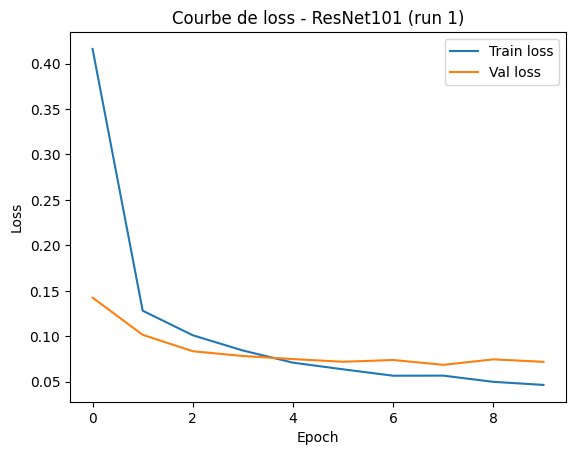

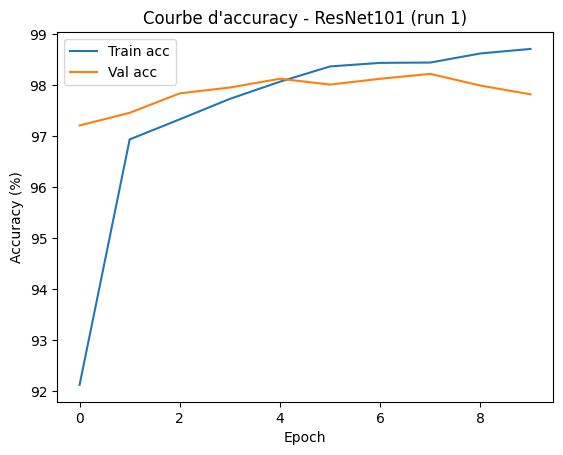

In [9]:
# On prend le premier run ResNet comme exemple
hist_res = results_resnet[0]["history"]

# Loss
plt.figure()
plt.plot(hist_res["train_loss"], label="Train loss")
plt.plot(hist_res["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbe de loss - ResNet101 (run 1)")
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(hist_res["train_acc"], label="Train acc")
plt.plot(hist_res["val_acc"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Courbe d'accuracy - ResNet101 (run 1)")
plt.legend()
plt.show()


In [10]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

def plot_confusion_matrix(cm, class_names, title="Matrice de confusion"):
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar(im)
    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names)
    ax.set_ylabel("Vraies classes")
    ax.set_xlabel("Classes prédites")

    # Optionnel : annotations dans les cases
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

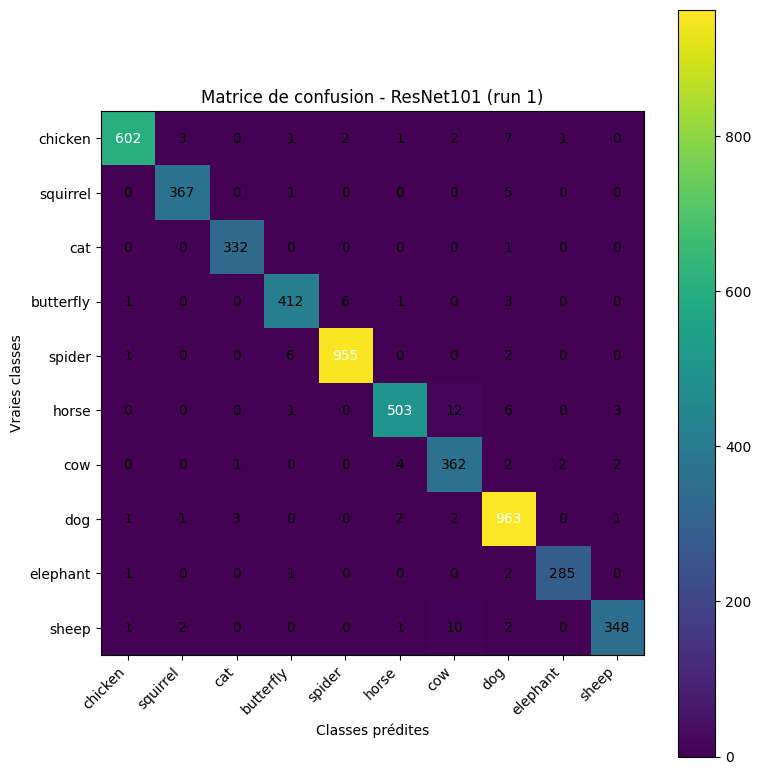

In [11]:
cm_res_run1 = results_resnet[0]["confusion_matrix"]
plot_confusion_matrix(
    cm_res_run1,
    [idx_to_class[i] for i in range(len(idx_to_class))],
    title="Matrice de confusion - ResNet101 (run 1)"
)